# Study 773 — Spotify-Wrapped 🎧

*For the curious.* Every December, **Spotify Wrapped** takes over your feed — the viral, personalised year-in-review that everyone screenshots. The folklore trade: buy SPOT into the launch, because all that free buzz surely lifts the stock. We put the 8 post-IPO Wrapped seasons (2018→2025) on the stand and asked two plain questions: **does SPOT rally into the launch?** and **does it fade after?** The answer is a double bust.

## The claim, and why it's a clean test

Wrapped ships in the same **late-Nov/early-Dec slot every year** (Nov 29 → Dec 6 since 2016), so the date is known well in advance. That makes *buy K sessions before, sell on the launch* calendar-known and zero-look-ahead. We measure SPOT's **abnormal** return (SPOT − SPY, total-return) so we're not just measuring beta. Caveat up front: SPOT only lists in April 2018, so this is a thin **n = 8** sample.

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..", "..", "..")))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from spotify_wrapped import data as dt, strategy as st

if not dt.have_real():
    print("cache miss -> fetching SPOT + SPY once (needs network)")
    dt.fetch()
prices = dt.load_real()
ev = st.build_event_table(prices, cost_bps=5.0)
inc = ev[ev["included"]]
print(f"panel loaded; {len(inc)} of {len(dt.EVENTS)} Wrapped launches resolved")


panel loaded; 8 of 10 Wrapped launches resolved


## The Wrapped calendar we test (hardcoded from Spotify Newsroom / Wikipedia)

2016 and 2017 are carried for completeness but have no SPOT tape (the direct listing is 2018-04-03), so they're excluded downstream.

In [2]:
pd.DataFrame(dt.EVENTS, columns=['year', 'wrapped_launch_date'])

,year,wrapped_launch_date
0,2016,2016-12-06
1,2017,2017-12-05
2,2018,2018-12-06
3,2019,2019-12-05
4,2020,2020-12-01
5,2021,2021-12-01
6,2022,2022-11-30
7,2023,2023-11-29
8,2024,2024-12-04
9,2025,2025-12-03


## The picture: mean cumulative abnormal return around the launch

Offset 0 is the Wrapped launch. Left of zero is the *run-up* (the supposed rally in); right of zero is the *fade* window.

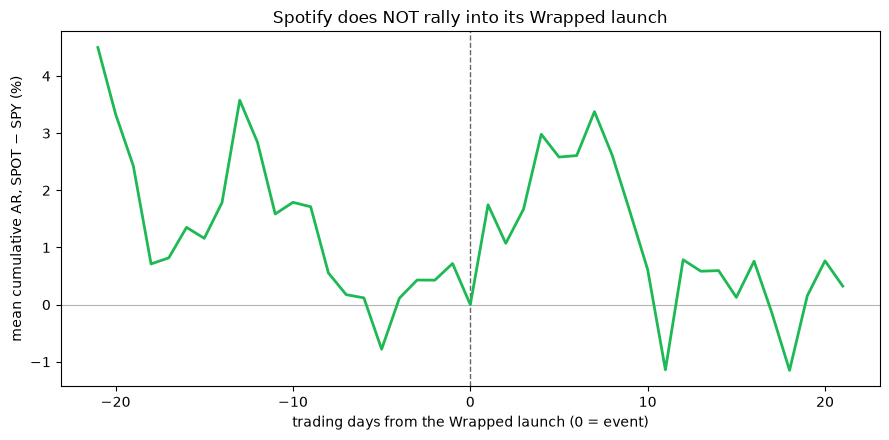

In [3]:
car = st.car_path(ev, prices)
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.axvline(0, color='0.4', lw=1, ls='--')
ax.axhline(0, color='0.7', lw=0.8)
ax.plot(car.index, car.values * 100, color='#1DB954', lw=2)
ax.set_xlabel('trading days from the Wrapped launch (0 = event)')
ax.set_ylabel('mean cumulative AR, SPOT − SPY (%)')
ax.set_title('Spotify does NOT rally into its Wrapped launch')
plt.tight_layout(); plt.show()

## The numbers

| window | mean AR | *t* | hit rate |
|---|--:|--:|--:|
| 2-week run-up | -0.68% | -0.18 | 5/8 |
| 1-month run-up | -1.94% | -0.37 | 3/8 |
| 2-week fade | +0.61% | +0.24 | 4/8 |
| 1-month fade | +0.32% | +0.15 | 4/8 |

The bullish folklore is simply **absent**: both run-up windows are mildly *negative* (-0.68% and -1.94%), and every single *t* is under 0.4 in magnitude. The 'sell the news' fade? A clean +0.3–0.6% wisp, a dead 50/50 hit rate. Nothing here is distinguishable from noise.

In [4]:
rows = [('2wk run-up','pre_s'),('1mo run-up','pre_l'),('2wk fade','post_s'),('1mo fade','post_l')]
for label, col in rows:
    s = st.one_sample_t(inc[col].values); hr = st.hit_rate(inc[col].values)
    print(f'{label:<12s} n={s["n"]:2d}  mean={s["mean"]*100:+.3f}%  t={s["t"]:+.3f}  hit {hr["k"]}/{hr["n"]}')

2wk run-up   n= 8  mean=-0.676%  t=-0.177  hit 5/8
1mo run-up   n= 8  mean=-1.940%  t=-0.373  hit 3/8
2wk fade     n= 8  mean=+0.614%  t=+0.239  hit 4/8
1mo fade     n= 8  mean=+0.324%  t=+0.152  hit 4/8


## So what?

The 'buy Spotify into Wrapped' trade is folklore. The stock doesn't rally in (it mildly, insignificantly sags) and it doesn't fade after. On just 8 post-IPO events, every cut sits dead-centre of its own noise — and SPOT's ordinary two-week swings (placebo sd ≈ 2.9%) dwarf any 'Wrapped' tilt. Verdict: **Signal None, Tradability Mirage.** The quants' notebook has the placebo, the jackknife, the costed leg and the synthetic control.